In [7]:
# conda create --name bcitoolbox python=3.10

from bcitoolbox_local import simulateVV
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from helpers import get_best_models, get_subject_ids

plot_indiv = False
location = 'invisible'

In [8]:
strategy_map = {
    'Averaging': 'ave',
    'Selection': 'sel',
    'Matching': 'mat',
}

def simulate_data(parameters, strategy_name, fitType, file_name,
                  modeling_data_path='csv/modeling/data/',
                  n_simulation=10000, biOnly=0):
    
    data_file_path = modeling_data_path + file_name
    behavior_data = np.loadtxt(data_file_path, delimiter=',')
    if len(behavior_data) < 10: return

    strategy = strategy_map.get(strategy_name[0])

    error, modelprop, dataprop, responsesSim, r2 = simulateVV(parameters, 
                                                              n_simulation, 
                                                              behavior_data, 
                                                              biOnly,
                                                              strategy, 
                                                              fitType,)

    return error, modelprop, dataprop, responsesSim, r2


In [9]:
# Simulate data for each subject
condition_map = None
best_models_df = get_best_models('bci', sigma_a=0.2)
# best_models_df = find_best_model_per_subject()
all_props = defaultdict(dict)

for location in [location]: 
    location_df = best_models_df[best_models_df['location'] == location]

    for index, row in location_df.iterrows():
        subject = row['subject_id']
        file_name = f"{subject}_{location}.csv"
        Strategies = [row['strategy']]
        FitType = row['fit_type']
        model = 'bci'

        if condition_map is None:
            behavior_data = np.loadtxt(f'csv/modeling/data/{file_name}', delimiter=',')
            stimuli = behavior_data[:, [0, 1]]
            condition_map = np.unique(stimuli, axis=0)
            print("condition_map.shape:", condition_map.shape)

        print("\n=======================================")
        print(f"Simulating data for {subject} at {location}")
        print("=======================================\n")

        parameters = [
            row['pcommon'],
            row['sigma_v'],
            row['sigma_a'],
            row['mu_p'],
            row['sigma_p'],            
        ]
        results = simulate_data(parameters, Strategies, FitType, file_name)

        if results is not None:
            error, modelprop, dataprop, responsesSim, r2 = results
            # store simulated data
            all_props[subject][location] = {
                'modelprop': modelprop,
                'dataprop': dataprop,
                'r2': r2
            }

            # Split modelprop and dataprop according to conditions
            for i, condition in enumerate(condition_map):
                all_props[subject][location][f'F{int(condition[0])}B{int(condition[1])}'] = {
                    'model': model,
                    'Visual model': modelprop[0, i, :],
                    'Visual response': dataprop[0, i, :],
                }

condition_map.shape: (4, 2)

Simulating data for LV001 at invisible

fit type = mll
===== DEBUG: fixed values = [0.5, 0.4, 0.8, 4000, 2, 0, 0] =====
===== DEBUG: pcommon = 0.1208798691176651 =====
===== DEBUG: sigma_v = 0.4412213420338129 =====
===== DEBUG: sigma_a = 0.2 =====
===== DEBUG: sigma_p = 1.5 =====
===== DEBUG: mu_p = 1.812701089794534 =====
R2 on all
0.37455397262117845
Sum Loglike    Optimal
-1108.4475532003512 -228.87982208797575
Explainable variance, r2:
-0.02403555731764495

Simulating data for LV002 at invisible

fit type = mll
===== DEBUG: fixed values = [0.5, 0.4, 0.8, 4000, 2, 0, 0] =====
===== DEBUG: pcommon = 0.9999863547816554 =====
===== DEBUG: sigma_v = 0.7418661785768073 =====
===== DEBUG: sigma_a = 0.2 =====
===== DEBUG: sigma_p = 1.5 =====
===== DEBUG: mu_p = 2.9999399541665674 =====
R2 on all
0.6512268406773907
Sum Loglike    Optimal
-1059.9095045351332 -220.12779541730015
Explainable variance, r2:
0.5194963257595019

Simulating data for LV003 at invisible


<Figure size 640x480 with 0 Axes>

In [10]:
vis_col = '#6636a5'
resp_col = '#9b72cf'

subject_ids = get_subject_ids()

if plot_indiv:
    for subject_id in subject_ids:
        # start plotting
        fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(7, 2), sharey=True)
        flattened_axes = axes.flatten()
        ax=0

        for condition in ['F0B0', 'F1B0', 'F1B1', 'F1B2']:            
            flattened_axes[ax].plot(all_props[subject_id][location][condition]['Visual response'], resp_col, label='Visual response')
            flattened_axes[ax].plot(all_props[subject_id][location][condition]['Visual model'], vis_col, linestyle='--', label='Visual model')
            model = all_props[subject_id][location][condition]['model']

            # aesthetics
            flattened_axes[ax].set_ylabel('Probability') if condition=='F0B0' else flattened_axes[ax].set_ylabel('')
            flattened_axes[ax].set_title(f'{condition}')

            ax+=1

        plt.suptitle(f'{subject_id}', fontsize='15', fontweight='bold')
        fig.subplots_adjust(top=0.75, wspace=0.1)

        # legend
        handles, labels = flattened_axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper left', fontsize=9, ncol=2)

        # plt.show()


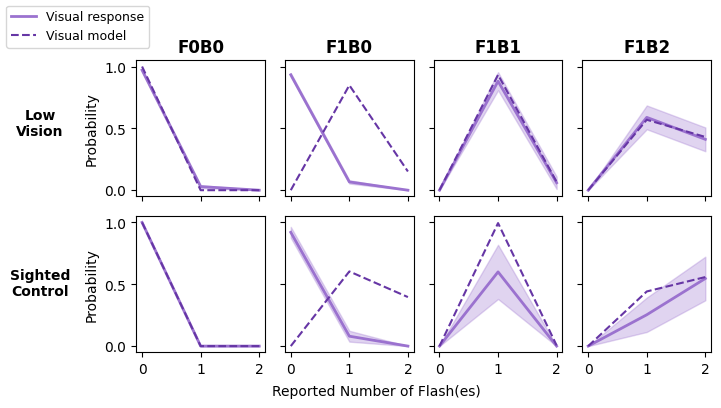

In [11]:
# Plot group average

vis_col = '#6636a5'
resp_col = '#9b72cf'

groups = ['Low Vision', 'Sighted Control']
conditions = ['F0B0', 'F1B0', 'F1B1', 'F1B2']

group_data = {
    'Low Vision': {cond: {'resp': [], 'mod': []} for cond in conditions},
    'Sighted Control': {cond: {'resp': [], 'mod': []} for cond in conditions}
}

for sid in all_props.keys():
    group = 'Low Vision' if sid.startswith('LV') else 'Sighted Control'
    for cond in conditions:
        if location in all_props[sid] and cond in all_props[sid][location]:
            group_data[group][cond]['resp'].append(all_props[sid][location][cond]['Visual response'])
            group_data[group][cond]['mod'].append(all_props[sid][location][cond]['Visual model'])

stats = {group: {cond: {} for cond in conditions} for group in groups}

for group in groups:
    for cond in conditions:
        resp_stack = np.array(group_data[group][cond]['resp'])
        mod_stack = np.array(group_data[group][cond]['mod'])
        
        # True data
        stats[group][cond]['resp_mean'] = np.mean(resp_stack, axis=0)
        stats[group][cond]['resp_sem'] = np.std(resp_stack, axis=0) / np.sqrt(len(resp_stack))
        
        # Model predictions
        stats[group][cond]['mod_mean'] = np.mean(mod_stack, axis=0)
        stats[group][cond]['mod_sem'] = np.std(mod_stack, axis=0) / np.sqrt(len(mod_stack))


fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(7, 4), sharex=True, sharey=True)

for row, group in enumerate(groups):
    for col, condition in enumerate(conditions):
        ax = axes[row, col]
        data = stats[group][condition]
        x = np.arange(len(data['resp_mean'])) # x-axis indices
        
        ax.plot(x, data['resp_mean'], color=resp_col, label='Visual response', lw=2)
        ax.fill_between(x, data['resp_mean'] - data['resp_sem'], 
                        data['resp_mean'] + data['resp_sem'], color=resp_col, alpha=0.3)
        
        ax.plot(x, data['mod_mean'], color=vis_col, linestyle='--', label='Visual model', lw=1.5)
        ax.set_ylim(-0.05, 1.05)
        if col == 0:
            ax.set_ylabel('Probability')
        if row == 0:
            ax.set_title(condition, fontweight='bold')

fig.text(0.02, 0.7, 'Low\nVision', va='center', ha='center', fontweight='bold')
fig.text(0.02, 0.3, 'Sighted\nControl', va='center', ha='center', fontweight='bold')
fig.text(0.5, 0.02, 'Reported Number of Flash(es)', ha='center')

# legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', fontsize=9)

plt.tight_layout(rect=[0.05, 0.03, 1, 0.95])
plt.show()